In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [35]:
df = pd.read_csv('Electric Vehicle Battery Life.csv')
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [36]:
df.shape

(7565, 10)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   start_time           7565 non-null   object
 2   ambient_temperature  7565 non-null   int64 
 3   battery_id           7565 non-null   object
 4   test_id              7565 non-null   int64 
 5   uid                  7565 non-null   int64 
 6   filename             7565 non-null   object
 7   Capacity             2794 non-null   object
 8   Re                   1956 non-null   object
 9   Rct                  1956 non-null   object
dtypes: int64(3), object(7)
memory usage: 591.1+ KB


In [38]:
df = df.drop(columns=['start_time','battery_id','test_id','uid','filename']
             )
df.head(2)

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.6743047446975208,NaN,NaN
1,impedance,24,NaN,0.05605783343888099,0.20097016584458333


In [39]:
df.isnull().sum()

type                      0
ambient_temperature       0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   ambient_temperature  7565 non-null   int64 
 2   Capacity             2794 non-null   object
 3   Re                   1956 non-null   object
 4   Rct                  1956 non-null   object
dtypes: int64(1), object(4)
memory usage: 295.6+ KB


In [41]:
df['Re'] = pd.to_numeric(df['Re'], errors='coerce')
df['Rct'] = pd.to_numeric(df['Rct'], errors='coerce')
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')

In [42]:
df.Re.fillna(df.Re.mean(), inplace=True)
df.Rct.fillna(df.Rct.mean(), inplace=True)
df.Capacity.fillna(df.Capacity.mean(), inplace=True)

C:\Users\Nayan\AppData\Local\Temp\ipykernel_38148\971570136.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Re.fillna(df.Re.mean(), inplace=True)
C:\Users\Nayan\AppData\Local\Temp\ipykernel_38148\971570136.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7565 non-null   object 
 1   ambient_temperature  7565 non-null   int64  
 2   Capacity             7565 non-null   float64
 3   Re                   7565 non-null   float64
 4   Rct                  7565 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 295.6+ KB


In [44]:
for i in df.columns:
    print(df[i].unique())
    print("======================================")

['discharge' 'impedance' 'charge']
[ 4 24 22 43 44]
[1.67430474 1.32654324 1.52436621 ... 1.01271214 1.020138   0.99075917]
[-4.97649950e+11  5.60578334e-02  5.31918585e-02 ...  9.77872215e-02
  9.86793636e-02  9.68087979e-02]
[1.05590312e+12 2.00970166e-01 1.64733999e-01 ... 1.50885241e-01
 1.52746632e-01 1.54897382e-01]


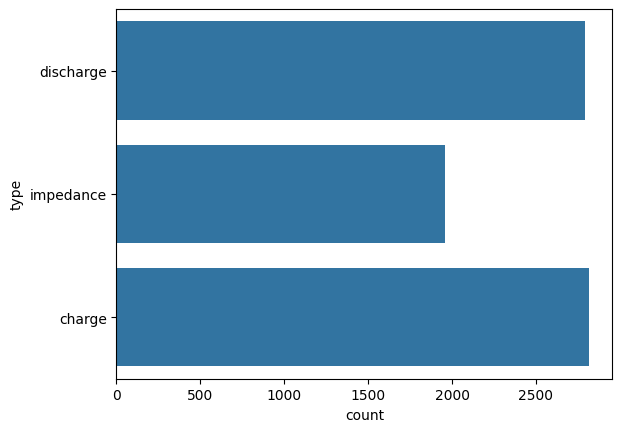

In [45]:
sns.countplot(df.type)
plt.show()

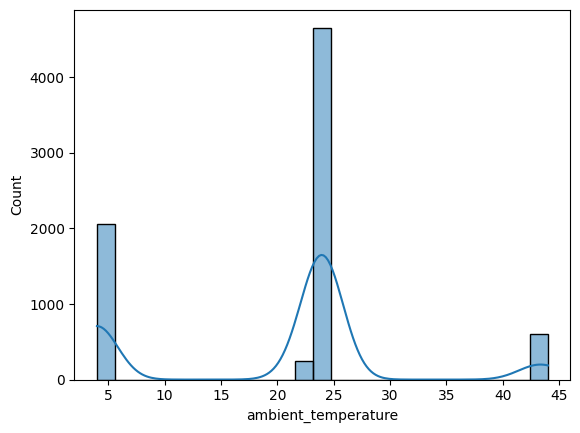

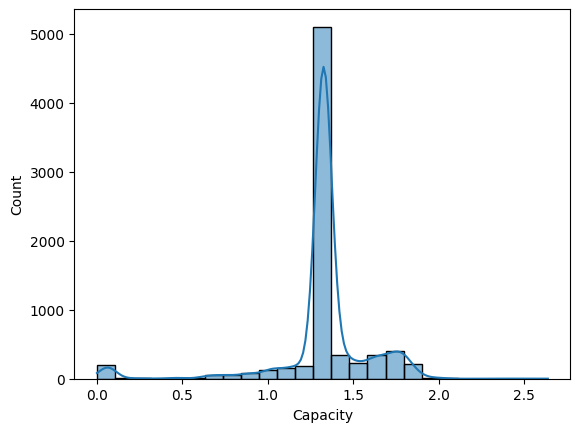

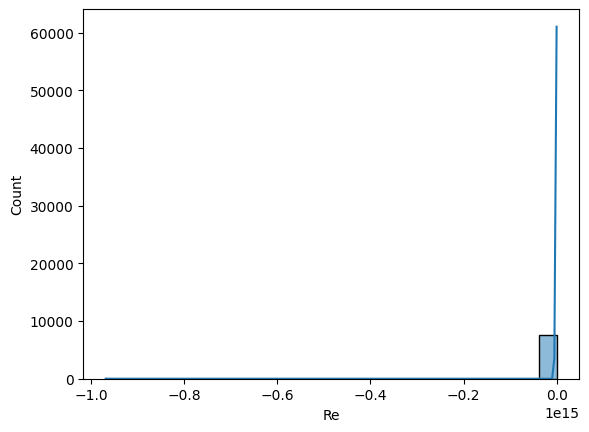

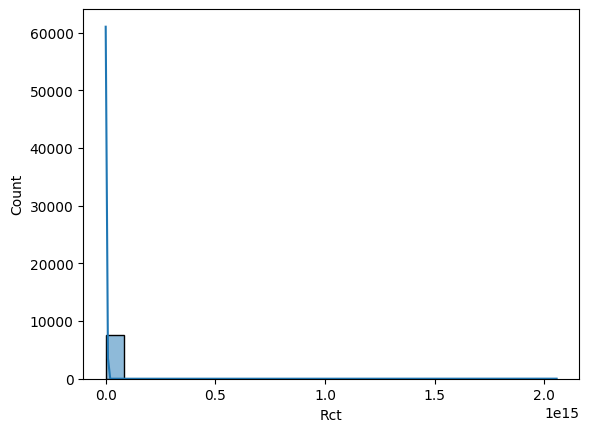

In [46]:
for i  in df.select_dtypes(exclude='object').columns:
    sns.histplot(df[i], kde=True, bins=25)
    plt.show()

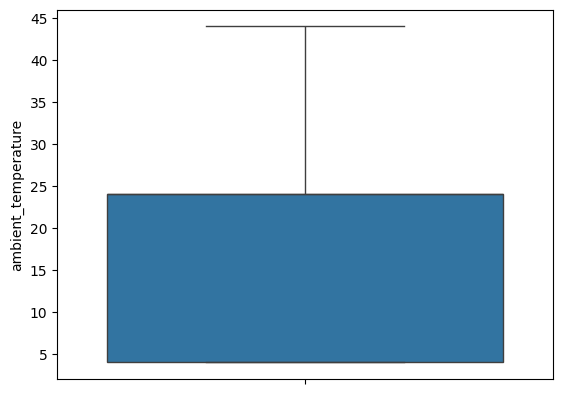

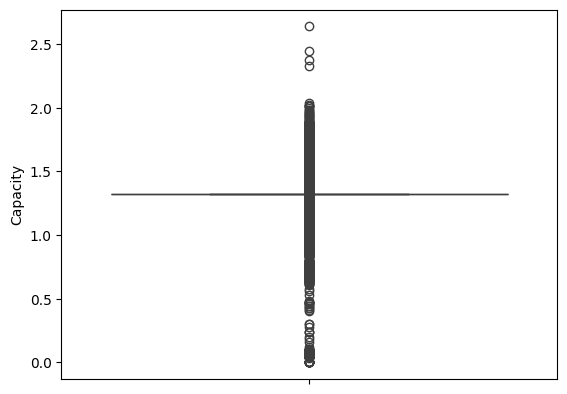

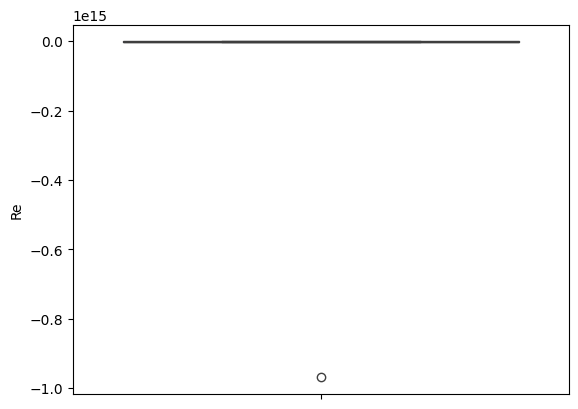

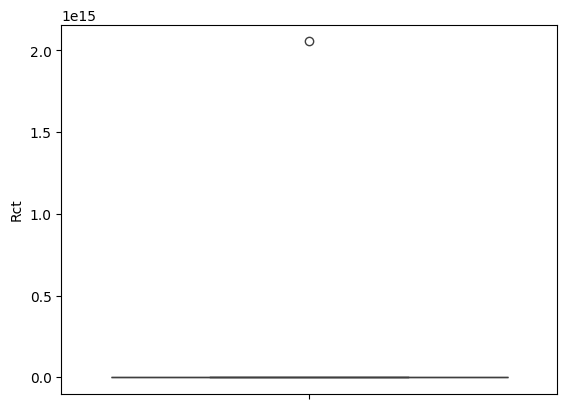

In [48]:
for i  in df.select_dtypes(exclude='object').columns:
    sns.boxplot(df[i])
    plt.show()

In [ ]:
label = LabelEncoder()
df.type = label.fit_transform(df.type)
df.head(20)

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
x = df.drop(columns=['ambient_temperature'])
y = df.ambient_temperature

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=61)

In [ ]:
scaler = MinMaxScaler()
x_train_Scaled = scaler.fit_transform(x_train)
x_test_Scaled = scaler.transform(x_test)

In [ ]:
x_train_tensor = torch.tensor(x_train_Scaled, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_Scaled, dtype=torch.float32)

In [ ]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [ ]:
train_tensor = TensorDataset(x_train_tensor, y_train_tensor)
test_tensor = TensorDataset(x_test_tensor, y_test_tensor)

In [ ]:
train_db = DataLoader(train_tensor, batch_size=32, shuffle=True)
test_db = DataLoader(test_tensor, batch_size=32, shuffle=False)

In [ ]:
x_train.shape

In [ ]:
class BatteryModel(nn.Module):
    def __init__(self):
        super(BatteryModel, self).__init__()
        self.flat = nn.Flatten()
        self.seq = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16,1)
        )
    def forward(self, x):
        return self.seq(self.flat(x))

In [ ]:
model = BatteryModel()
model

In [ ]:
criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

In [ ]:
epochs = 100

for ep in range(0,epochs):
    model.train()
    run_loss = 0.0

    for ip, target in train_db:
        optimizer.zero_grad()
        op = model(ip)
        loss = criteria(op, target)
        loss.backward()
        optimizer.step()
        run_loss += loss.item()

    ep_loss = run_loss/len(train_db.dataset)

    if(ep+1)%10 == 0:
        print(f"Epoch [{ep+1}/{epochs}], Loss: {ep_loss:.4f}")

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(x_train_tensor)

    # loss (correct)
    test_loss = criteria(preds, y_train_tensor.view(-1))
    print(f"\n✅ Train Loss: {test_loss.item():.4f}")

    # convert logits → predicted class
    predicted_classes = torch.argmax(preds, dim=1)

    # convert to numpy
    y_true = y_train_tensor.view(-1).cpu().numpy()
    y_pred = predicted_classes.cpu().numpy()

In [ ]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    
    outputs = model(x_train_tensor)
    loss = criteria(outputs, y_train_tensor.view(-1))
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_test_tensor)
        val_loss = criteria(val_outputs, y_test_tensor.view(-1))
        val_losses.append(val_loss.item())
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

acc = root_mean_squared_error(y_true, y_pred)
print(f"root mean_squared_error Score: {acc:.3f}")

acc = mean_absolute_error(y_true, y_pred)
print(f"mean_absolute error Score: {acc:.3f}")

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(x_test_tensor)

    # compute test loss
    test_loss = criteria(preds, y_test_tensor.view(-1))
    print(f"\n✅ Test Loss: {test_loss.item():.4f}")

    # convert logits → predicted class
    predicted_classes = torch.argmax(preds, dim=1)

    # numpy conversion
    y_true = y_test_tensor.view(-1).cpu().numpy()
    y_pred = predicted_classes.cpu().numpy()

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

acc = root_mean_squared_error(y_true, y_pred)
print(f"root mean_squared_error Score: {acc:.3f}")

acc = mean_absolute_error(y_true, y_pred)
print(f"mean_absolute error Score: {acc:.3f}")

In [ ]:
r2_score(y_test, y_pred)